  IC3392: 14884 HII pixels
  NGC4064: 6820 HII pixels
  NGC4064: 6820 HII pixels
  NGC4192: 145934 HII pixels
  NGC4293: 3854 HII pixels
  NGC4192: 145934 HII pixels
  NGC4293: 3854 HII pixels
  NGC4298: 156350 HII pixels
  NGC4298: 156350 HII pixels
  NGC4330: 42566 HII pixels
  NGC4383: 75127 HII pixels
  NGC4330: 42566 HII pixels
  NGC4383: 75127 HII pixels
  NGC4396: 81728 HII pixels
  NGC4419: 6886 HII pixels
  NGC4396: 81728 HII pixels
  NGC4419: 6886 HII pixels
  NGC4457: 6000 HII pixels
  NGC4457: 6000 HII pixels
  NGC4501: 260854 HII pixels
  NGC4522: 39354 HII pixels
  NGC4501: 260854 HII pixels
  NGC4522: 39354 HII pixels
  NGC4694: 2585 HII pixels
  NGC4694: 2585 HII pixels
  NGC4698: 10042 HII pixels

Total combined HII pixels: 852984
  NGC4698: 10042 HII pixels

Total combined HII pixels: 852984

=== Combined BPT Diagram Summary (HII only) ===
  N2 BPT - Total HII: 852984 (100.0%)
  S2 BPT - Total HII: 852984 (100.0%)

Galaxy breakdown for HII spaxels:
  IC3392: N2_HII=14

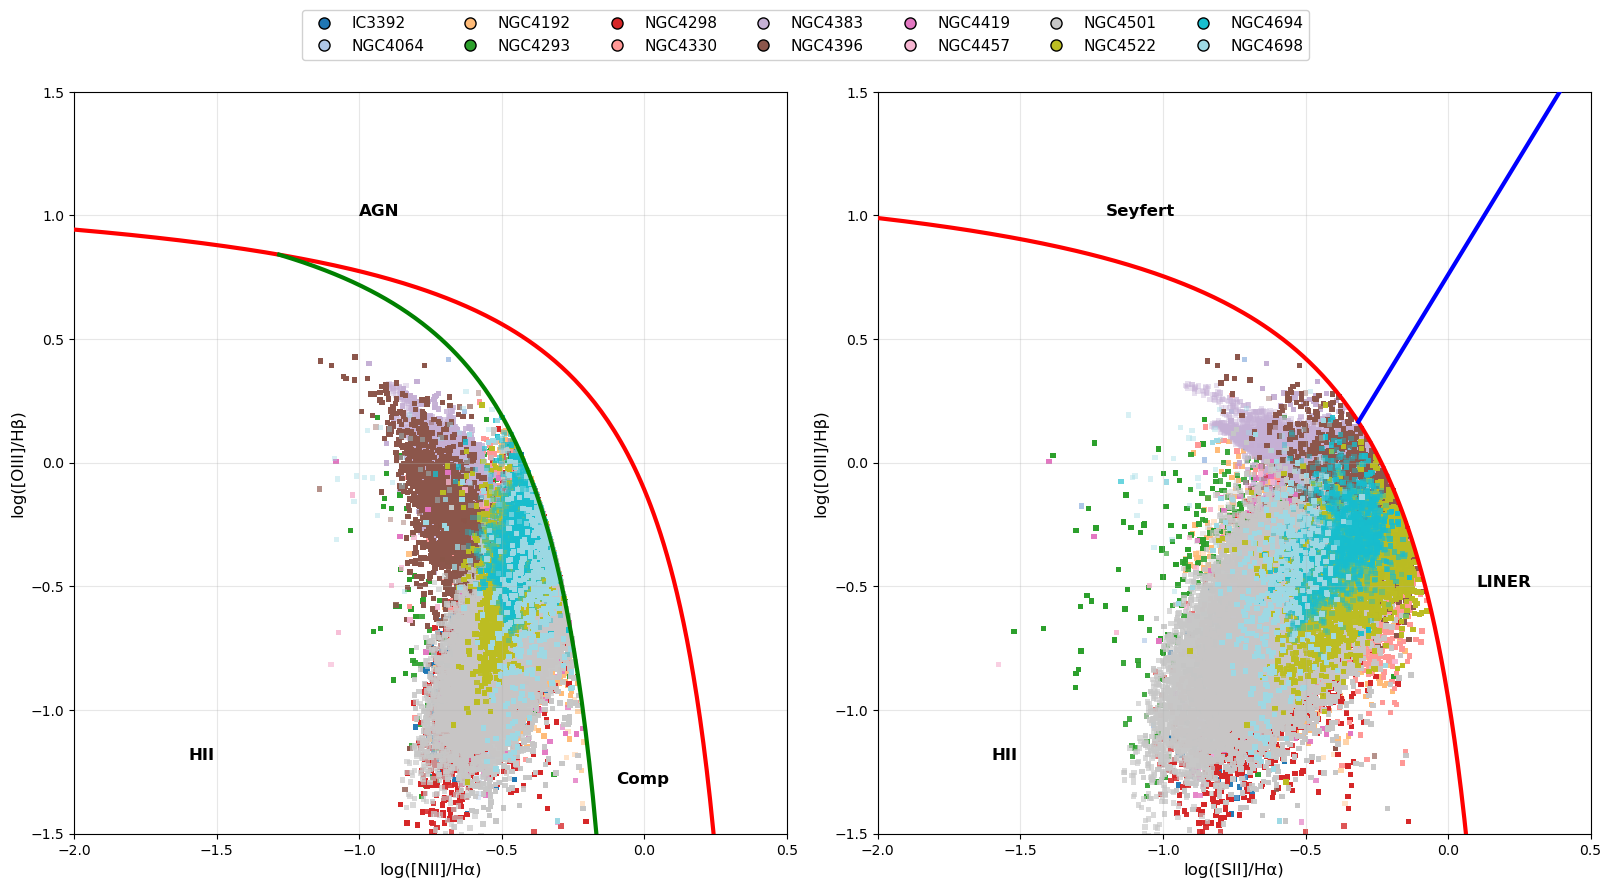

In [1]:
# ------------------------------------------------------------------
# Combined Analysis: NII and SII BPT Diagrams - Color-coded by Galaxy
# Collect all HII spaxels from all galaxies (HII only, no SF)
# Uses common spaxels across all 4 metallicity calibrations
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
from astropy.io import fits

# BPT reference line functions
def kewley01_N2(x):   # max-starburst
    return 0.61/(x-0.47) + 1.19

def kauff03_N2(x):    # empirical SF upper envelope
    return 0.61/(x-0.05) + 1.30

def kewley01_S2(x):
    return 0.72/(x-0.32) + 1.30

def kewley06_Sy_LIN(x):   # Seyfert/LINER division
    return 1.89*x + 0.76

# Create x arrays for the theoretical lines
x_kewley_N2 = np.linspace(-2.0, 0.3, 200)
x_kauff_N2 = np.linspace((286-np.sqrt(2871561))/1100, 0.0, 200)
x_kewley_S2 = np.linspace(-2.0, 0.3, 200)
x_kewley06_S2 = np.linspace((159-np.sqrt(105081))/525, 0.5, 200)

# Get all galaxies from binning files
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

# Create galaxy color mapping (consistent for all HII regions)
galaxy_colors = plt.cm.tab20(np.linspace(0, 1, len(galaxies)))
galaxy_color_dict = dict(zip(galaxies, galaxy_colors))

# Collect all spaxels from all galaxies - HII only (with galaxy indices)
all_logN2_hii = []
all_logO3_hii = []
all_logS2_hii = []
all_galaxy_indices_hii = []

print("Collecting HII data from all galaxies...")
for gal_idx, gal in enumerate(galaxies):
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')
    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')

    if gas_file.exists() and bin_file.exists():
        # Load maps for this galaxy
        with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
            logSigmaM = h['LOGMASS_SURFACE_DENSITY'].data
        with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
            # HII quantities
            logSigmaSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
            oh_d16_HII = h['O_H_D16_HII'].data
            oh_pg16_HII = h['O_H_PG16_HII'].data
            oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
            oh_o3n2_c20_HII = h['O_H_O3N2_C20_HII'].data

            # Load corrected emission line fluxes
            HB4861_FLUX_corr = h['HB4861_FLUX_corr'].data
            HA6562_FLUX_corr = h['HA6562_FLUX_corr'].data
            OIII5006_FLUX_corr = h['OIII5006_FLUX_corr'].data
            NII6583_FLUX_corr = h['NII6583_FLUX_corr'].data
            SII6716_FLUX_corr = h['SII6716_FLUX_corr'].data
            SII6730_FLUX_corr = h['SII6730_FLUX_corr'].data

        # Find common spaxels for HII
        common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                           np.isfinite(oh_d16_HII) & np.isfinite(oh_pg16_HII) & 
                           np.isfinite(oh_o3n2_m13_HII) & np.isfinite(oh_o3n2_c20_HII) &
                           np.isfinite(HB4861_FLUX_corr) & np.isfinite(HA6562_FLUX_corr) &
                           np.isfinite(OIII5006_FLUX_corr) & np.isfinite(NII6583_FLUX_corr) &
                           np.isfinite(SII6716_FLUX_corr) & np.isfinite(SII6730_FLUX_corr))

        n_pixels_HII = np.sum(common_mask_HII)
        print(f"  {gal}: {n_pixels_HII} HII pixels")

        # Apply common_mask to get valid spaxels - HII
        HB_common_HII = HB4861_FLUX_corr[common_mask_HII]
        HA_common_HII = HA6562_FLUX_corr[common_mask_HII]
        OIII_common_HII = OIII5006_FLUX_corr[common_mask_HII]
        NII_common_HII = NII6583_FLUX_corr[common_mask_HII]
        SII6716_common_HII = SII6716_FLUX_corr[common_mask_HII]
        SII6730_common_HII = SII6730_FLUX_corr[common_mask_HII]

        # Calculate line ratios - HII
        logN2_hii = np.log10(NII_common_HII / HA_common_HII)
        logO3_hii = np.log10(OIII_common_HII / HB_common_HII)
        logS2_hii = np.log10((SII6716_common_HII + SII6730_common_HII) / HA_common_HII)

        # Append to combined arrays - HII only
        all_logN2_hii.extend(logN2_hii.flatten())
        all_logO3_hii.extend(logO3_hii.flatten())
        all_logS2_hii.extend(logS2_hii.flatten())
        all_galaxy_indices_hii.extend([gal_idx] * len(logN2_hii.flatten()))
    else:
        print(f"  {gal}: Data files not found")

# Convert to numpy arrays - HII
all_logN2_hii = np.array(all_logN2_hii)
all_logO3_hii = np.array(all_logO3_hii)
all_logS2_hii = np.array(all_logS2_hii)
all_galaxy_indices_hii = np.array(all_galaxy_indices_hii)

print(f"\nTotal combined HII pixels: {len(all_logN2_hii)}")

# Apply BPT classifications - HII only
mask_N2_HII = all_logO3_hii <= kauff03_N2(all_logN2_hii)
mask_N2_Comp = (all_logO3_hii > kauff03_N2(all_logN2_hii)) & (all_logO3_hii <= kewley01_N2(all_logN2_hii))
mask_N2_AGN = all_logO3_hii > kewley01_N2(all_logN2_hii)

mask_S2_HII = all_logO3_hii <= kewley01_S2(all_logS2_hii)
mask_S2_above_kewley = all_logO3_hii > kewley01_S2(all_logS2_hii)
mask_S2_LINER = mask_S2_above_kewley & (all_logO3_hii <= kewley06_Sy_LIN(all_logS2_hii))
mask_S2_Seyfert = mask_S2_above_kewley & (all_logO3_hii > kewley06_Sy_LIN(all_logS2_hii))

mask_HII_N2 = mask_N2_HII | mask_N2_Comp
mask_HII_S2 = mask_S2_HII

# Create BPT diagrams: HII only (single row, two panels)
# Use constrained_layout for better spacing with legend
fig, axes = plt.subplots(1, 2, figsize=(16, 8), constrained_layout=True)

# ===== HII REGIONS ONLY =====

# NII BPT Diagram - HII
ax = axes[0]

for gal_idx, gal in enumerate(galaxies):
    gal_mask = (all_galaxy_indices_hii == gal_idx) & mask_HII_N2
    if np.sum(gal_mask) > 0:
        ax.scatter(all_logN2_hii[gal_mask], all_logO3_hii[gal_mask], 
                   color=galaxy_colors[gal_idx], marker=',', s=15, alpha=0.4, 
                   edgecolors='none', rasterized=True)

ax.plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'r-', lw=3, label='Kewley+01', zorder=10)
ax.plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'g-', lw=3, label='Kauffmann+03', zorder=10)

hii_count_N2 = np.sum(mask_HII_N2)
total_common_hii = len(all_logN2_hii)
hii_percent_N2 = hii_count_N2 / total_common_hii * 100 if total_common_hii > 0 else 0

ax.set_xlabel('log([NII]/Hα)', fontsize=12)
ax.set_ylabel('log([OIII]/Hβ)', fontsize=12)
ax.set_xlim(-2.0, 0.5)
ax.set_ylim(-1.5, 1.5)
# ax.set_title('NII BPT (Common HII spaxels by Galaxy)', fontsize=14)
ax.text(-1.6, -1.2, 'HII', fontsize=12, fontweight='bold')
ax.text(-0.1, -1.3, 'Comp', fontsize=12, fontweight='bold')
ax.text(-1.0, 1.0, 'AGN', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# SII BPT Diagram - HII
ax = axes[1]

for gal_idx, gal in enumerate(galaxies):
    gal_mask = (all_galaxy_indices_hii == gal_idx) & mask_HII_S2
    if np.sum(gal_mask) > 0:
        ax.scatter(all_logS2_hii[gal_mask], all_logO3_hii[gal_mask], 
                   color=galaxy_colors[gal_idx], marker=',', s=15, alpha=0.4, 
                   edgecolors='none', rasterized=True)

ax.plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'r-', lw=3, label='Kewley+01', zorder=10)
ax.plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'b-', lw=3, label='Kewley+06', zorder=10)

hii_count_S2 = np.sum(mask_HII_S2)
hii_percent_S2 = hii_count_S2 / total_common_hii * 100 if total_common_hii > 0 else 0

ax.set_xlabel('log([SII]/Hα)', fontsize=12)
ax.set_ylabel('log([OIII]/Hβ)', fontsize=12)
ax.set_xlim(-2.0, 0.5)
ax.set_ylim(-1.5, 1.5)
# ax.set_title('SII BPT (Common HII spaxels by Galaxy)', fontsize=14)
ax.text(-1.6, -1.2, 'HII', fontsize=12, fontweight='bold')
ax.text(-1.2, 1.0, 'Seyfert', fontsize=12, fontweight='bold')
ax.text(0.1, -0.5, 'LINER', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Build custom legend handles with larger markers
legend_handles = []
legend_labels = []
for gal_idx, gal in enumerate(galaxies):
    legend_handles.append(Line2D([0], [0], marker='o', color='none', 
                                 markerfacecolor=galaxy_colors[gal_idx], markersize=8, linestyle='None'))
    legend_labels.append(f'{gal}')

# Put legend above the axes at 1.1 (outside plot)
fig.legend(legend_handles, legend_labels, loc='upper center',
           bbox_to_anchor=(0.5, 1.1),
           ncol=min(len(legend_labels), 7), fontsize=11, framealpha=0.9)

# Save PNG tightly cropped, PDF with standard bbox (no cropping of legend)
fig.savefig('Plot_Paper_1/Combined_BPT_diagrams_by_Galaxy_HII.png', dpi=600, bbox_inches='tight', pad_inches=0.05)
fig.savefig('Plot_Paper_1/Combined_BPT_diagrams_by_Galaxy_HII.pdf', dpi=600, bbox_inches='tight', pad_inches=0.05)

# Print summary statistics (HII only)
print(f"\n=== Combined BPT Diagram Summary (HII only) ===")
print(f"  N2 BPT - Total HII: {hii_count_N2} ({hii_percent_N2:.1f}%)")
print(f"  S2 BPT - Total HII: {hii_count_S2} ({hii_percent_S2:.1f}%)")

# Print galaxy breakdown for HII spaxels
print(f"\nGalaxy breakdown for HII spaxels:")
for gal_idx, gal in enumerate(galaxies):
    gal_n2 = np.sum((all_galaxy_indices_hii == gal_idx) & mask_HII_N2)
    gal_s2 = np.sum((all_galaxy_indices_hii == gal_idx) & mask_HII_S2)
    print(f"  {gal}: N2_HII={gal_n2}, S2_HII={gal_s2}")

print(f"\nSuccessfully created combined BPT diagrams (HII only) colored by galaxy from {len(galaxies)} galaxies")
print(f"Galaxies included: {', '.join(galaxies)}")

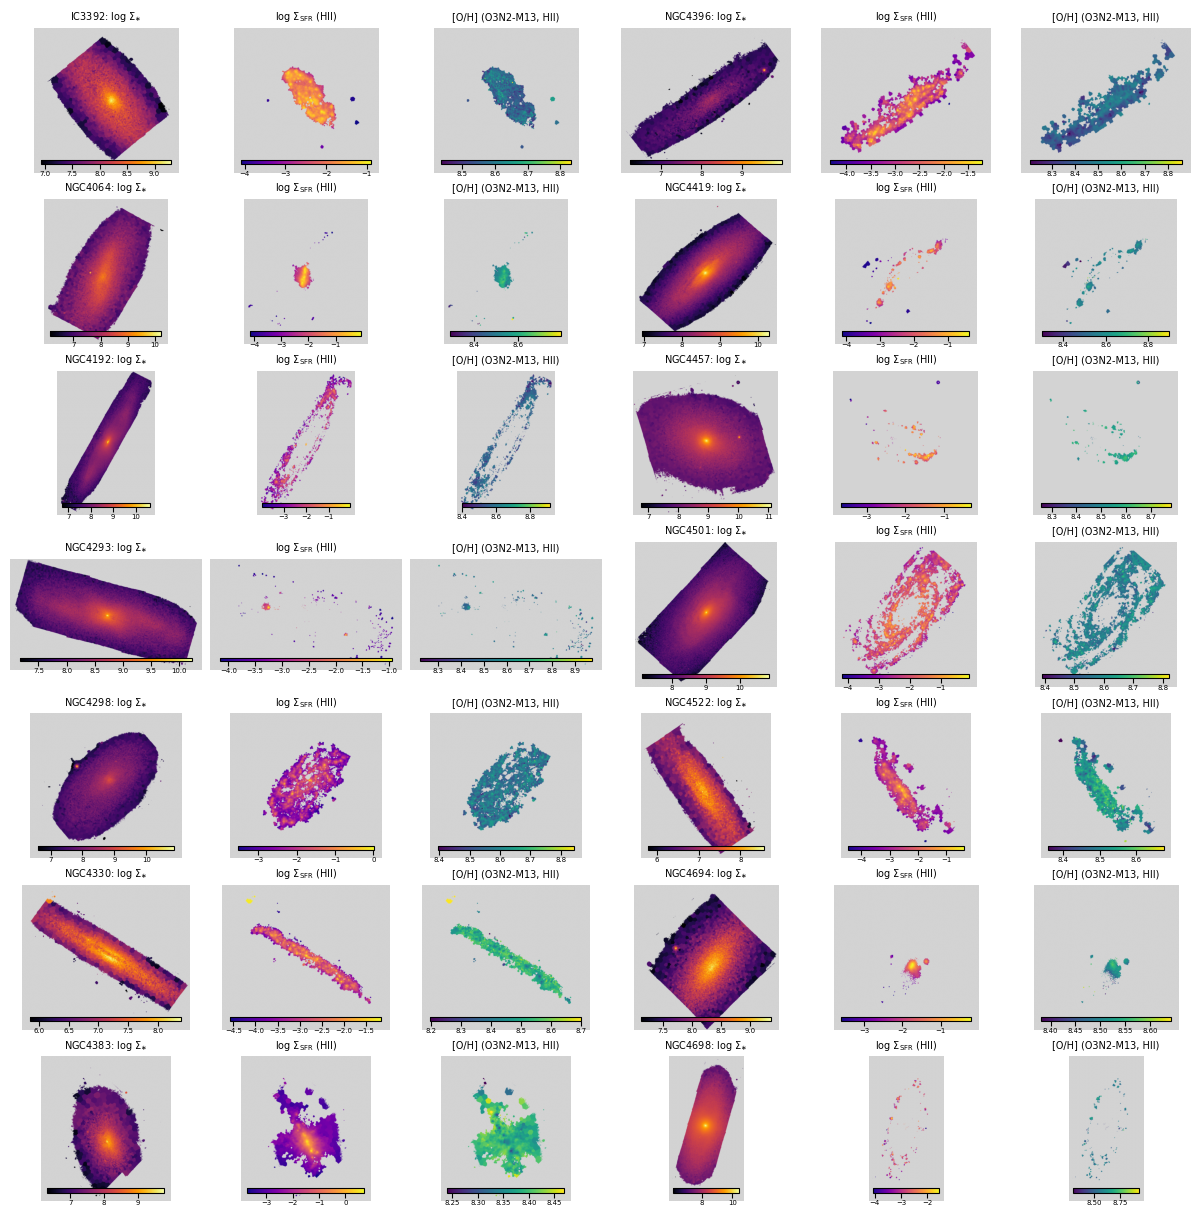

In [2]:
# --------------------------------------------------------------
# Maps: Σ_M*, Σ_SFR and [O/H] (O3N2-M13) maps for each galaxy
# Using HII spaxels (common HII for Σ_SFR and O/H only)
# Layout: up to 14 galaxies in 7 rows × 6 columns
# Columns per row: [Σ_M*, Σ_SFR, [O/H]] × 2 blocks
# --------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from pathlib import Path
from astropy.io import fits

# 0 · discover galaxies
gas_bins = sorted(Path('.').glob('*_gas_BIN_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in gas_bins]          # 14 expected
ngal     = len(galaxies)
assert ngal <= 14, "This layout assumes ≤ 14 galaxies."

# 1 · helpers to load maps (no mask for mass; HII mask for Σ_SFR and O/H)
def load_maps_hii(gal):
    """
    Load stellar-mass surface density (from spatial-binning file),
    Σ_SFR (HII), and [O/H] (O3N2-M13, HII) for a galaxy.

    - Σ_M* is shown wherever it is finite (no HII mask).
    - Σ_SFR and [O/H] use a common HII mask requiring both to be finite.
    """
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h_bin:
        logSigmaM = h_bin['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h_gas:
        sigSFR_HII     = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_o3n2m13_HII = h_gas['O_H_O3N2_M13_HII'].data

    # Mass: just require Σ_M* to be finite
    mass_mask   = np.isfinite(logSigmaM)
    logSigmaM_c = np.where(mass_mask, logSigmaM, np.nan)

    # HII common mask for Σ_SFR and O/H
    hii_mask        = (np.isfinite(sigSFR_HII) & np.isfinite(oh_o3n2m13_HII))
    sigSFR_HII_c    = np.where(hii_mask, sigSFR_HII, np.nan)
    oh_o3n2m13_c    = np.where(hii_mask, oh_o3n2m13_HII, np.nan)

    return logSigmaM_c, sigSFR_HII_c, oh_o3n2m13_c

# 2 · figure & GridSpec  (rows=7, cols=6 → two 3-column blocks per row)
# Use constrained_layout for better handling of colorbars and spacing
fig = plt.figure(figsize=(12, 12), constrained_layout=True)
gs  = GridSpec(
        nrows=7, ncols=6, figure=fig,
        width_ratios=[1, 1, 1, 1, 1, 1],      # [Σ_M*, Σ_SFR, [O/H]] × 2 blocks
        wspace=0.00, hspace=0.00
)

for idx, gal in enumerate(galaxies):
    row  = idx % 7                      # 0–6
    blk  = idx // 7                     # 0 or 1   (left / right 3-column block)
    col0 = blk * 3                      # 0 or 3   (start col of that block)

    logSigmaM_c, sigSFR_HII_c, oh_o3n2m13_c = load_maps_hii(gal)

    # Σ_M* map with NaN shown as light gray
    axM = fig.add_subplot(gs[row, col0])
    cmap_M = plt.cm.inferno.copy(); cmap_M.set_bad('lightgray')
    imM = axM.imshow(logSigmaM_c, origin='lower', cmap=cmap_M)
    axM.set_title(rf'{gal}: $\log\,\Sigma_{{\ast}}$', fontsize=7)
    axM.axis('off')
    caxM = inset_axes(axM, width='90%', height='3%', loc='lower center', borderpad=0.6)
    fig.colorbar(imM, cax=caxM, orientation='horizontal')
    caxM.tick_params(labelsize=5, pad=1)

    # Σ_SFR (HII) map with NaN shown as light gray
    axS = fig.add_subplot(gs[row, col0+1])
    cmap_S = plt.cm.plasma.copy(); cmap_S.set_bad('lightgray')
    imS = axS.imshow(sigSFR_HII_c, origin='lower', cmap=cmap_S)
    axS.set_title(r'$\log\,\Sigma_{\mathrm{SFR}}$ (HII)', fontsize=7)
    axS.axis('off')
    caxS = inset_axes(axS, width='90%', height='3%', loc='lower center', borderpad=0.6)
    fig.colorbar(imS, cax=caxS, orientation='horizontal')
    caxS.tick_params(labelsize=5, pad=1)

    # [O/H] O3N2-M13 (HII) map with NaN shown as light gray
    axOH = fig.add_subplot(gs[row, col0+2])
    cmap_OH = plt.cm.viridis.copy(); cmap_OH.set_bad('lightgray')
    imOH = axOH.imshow(oh_o3n2m13_c, origin='lower', cmap=cmap_OH)
    axOH.set_title(r'[O/H] (O3N2-M13, HII)', fontsize=7)
    axOH.axis('off')
    caxOH = inset_axes(axOH, width='90%', height='3%', loc='lower center', borderpad=0.6)
    fig.colorbar(imOH, cax=caxOH, orientation='horizontal')
    caxOH.tick_params(labelsize=5, pad=1)

# Save figure in both PNG and PDF formats
# Add a little extra space below plots via pad_inches
fig.savefig('Plot_Paper_1/MAUVE_MUSE_SigmaM_SigmaSFR_OH_Maps_HII_6x7.png', dpi=600, bbox_inches='tight', pad_inches=0.05)
fig.savefig('Plot_Paper_1/MAUVE_MUSE_SigmaM_SigmaSFR_OH_Maps_HII_6x7.pdf', dpi=600, pad_inches=0.05)

plt.show()

STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...
  IC3392: HII=14884 pixels
  NGC4064: HII=7067 pixels
  NGC4192: HII=145944 pixels
  NGC4064: HII=7067 pixels
  NGC4192: HII=145944 pixels
  NGC4293: HII=5715 pixels
  NGC4298: HII=156350 pixels
  NGC4293: HII=5715 pixels
  NGC4298: HII=156350 pixels
  NGC4330: HII=42998 pixels
  NGC4383: excluded from analysis
  NGC4396: HII=81745 pixels
  NGC4330: HII=42998 pixels
  NGC4383: excluded from analysis
  NGC4396: HII=81745 pixels
  NGC4419: HII=7354 pixels
  NGC4457: HII=6310 pixels
  NGC4419: HII=7354 pixels
  NGC4457: HII=6310 pixels
  NGC4501: HII=261083 pixels
  NGC4522: HII=39665 pixels
  NGC4501: HII=261083 pixels
  NGC4522: HII=39665 pixels
  NGC4694: HII=2585 pixels
  NGC4698: HII=10181 pixels
  NGC4694: HII=2585 pixels
  NGC4698: HII=10181 pixels

Total combined pixels (HII): 781881

STEP 2: Defining 8 SFR bins for rMZR

Σ_SFR bins:
  Number of bins: 8

8 SFR bins:
  Bin 1: <-3.5
  Bin 2: -3.5–-3.0
  Bin

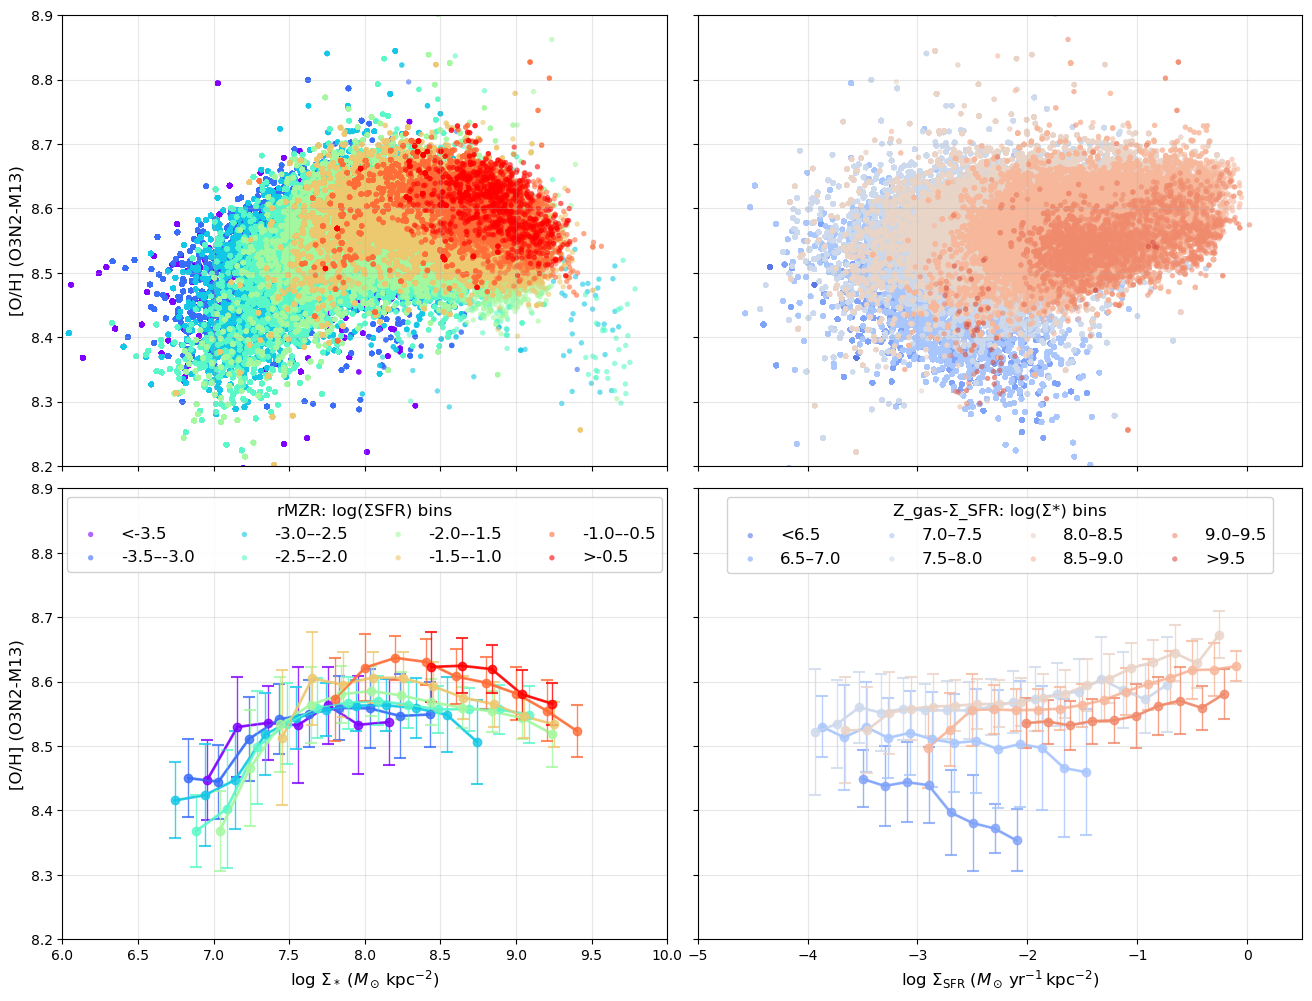


COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)
Successfully created 2x2 subplot figure showing HII regions from 13 galaxies
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Excluded: NGC4383

Panel summary:
  Top-left: rMZR scatter (8 Σ_SFR bins)
  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins)
  Bottom-left: rMZR median trends (8 Σ_SFR bins)
  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins)
  Shared y-range: 8.2 to 8.9


In [6]:
# ------------------------------------------------------------------
# Combined Analysis: rMZR and Z_gas-Σ_SFR relation - HII regions only
# Using O3N2-M13 indicator only
# 2x2 subplot layout:
#   Top-left: rMZR scatter
#   Top-right: Z_gas-Σ_SFR scatter
#   Bottom-left: rMZR median trends
#   Bottom-right: Z_gas-Σ_SFR median trends
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats

def load_maps_o3n2_m13(gal):
    """Load O3N2-M13 metallicity calibration for HII regions"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        # HII regions
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
    return (sigM, sigSFR_HII, oh_o3n2_m13_HII)

def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=20):
    """Calculate median and std in bins - only keep bins with >= 20 unique datapoints"""
    # Define bins
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    medians = []
    stds = []
    counts = []
    valid_centers = []
    valid_bin_indices = []
    
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        # Select data in this bin
        in_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_bin]
        
        if len(np.unique(y_in_bin)) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])
            valid_bin_indices.append(i)
    
    return (np.array(valid_centers), np.array(medians), np.array(stds), 
            np.array(counts), np.array(valid_bin_indices))

# Get all galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

# Galaxies to exclude entirely
excluded_galaxies = {'NGC4383'}
included_galaxies = []

# ==============================================================================
# STEP 1: Collect all spaxels from all galaxies for HII regions
# ==============================================================================
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_o3n2_m13_HII = []

print("="*80)
print("STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...")
print("="*80)

for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded from analysis")
        continue

    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

    if bin_file.exists() and gas_file.exists():
        included_galaxies.append(gal)
        # Load data for HII regions
        (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII) = load_maps_o3n2_m13(gal)

        # Find common spaxels for HII regions
        common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                           np.isfinite(oh_o3n2_m13_HII))
        
        print(f"  {gal}: HII={np.sum(common_mask_HII)} pixels")
        
        # Append HII data
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
    else:
        print(f"  {gal}: Data files not found")

# Convert to numpy arrays
all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)

print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")

# ==============================================================================
# STEP 2: Define 8 Σ_SFR bins for rMZR analysis
# Bins: <-3.5, [-3.5,-3.0), [-3.0,-2.5), [-2.5,-2.0), [-2.0,-1.5), [-1.5,-1.0), [-1.0,-0.5), >=-0.5
# ==============================================================================
print("\n" + "="*80)
print("STEP 2: Defining 8 SFR bins for rMZR")
print("="*80)

# Define 8 bins with specific boundaries
n_bins = 8
# Bin edges: -inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf
sfr_bin_edges = [-np.inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf]

print(f"\nΣ_SFR bins:")
print(f"  Number of bins: {n_bins}")

# Create bin labels
bin_labels = [
    '<-3.5',
    '-3.5–-3.0',
    '-3.0–-2.5',
    '-2.5–-2.0',
    '-2.0–-1.5',
    '-1.5–-1.0',
    '-1.0–-0.5',
    '>-0.5'
]

print(f"\n8 SFR bins:")
for i, label in enumerate(bin_labels):
    print(f"  Bin {i+1}: {label}")

# Colors for different bins using rainbow colormap
colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))

# ==============================================================================
# STEP 3: Define 8 Σ_* bins for Z_gas-Σ_SFR analysis
# Bins: <6.5, [6.5,7.0), [7.0,7.5), [7.5,8.0), [8.0,8.5), [8.5,9.0), [9.0,9.5), >=9.5
# ==============================================================================
print("\n" + "="*80)
print("STEP 3: Defining 8 Σ_* bins for Z_gas-Σ_SFR")
print("="*80)

# Define 8 Σ_* bins with specific boundaries
n_bins_sigmaM = 8
# Bin edges: -inf, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, +inf
sigmaM_bin_edges = [-np.inf, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, np.inf]

print(f"\nΣ_* bins:")
print(f"  Number of bins: {n_bins_sigmaM}")

# Create bin labels for Σ_* bins
bin_labels_sigmaM = [
    '<6.5',
    '6.5–7.0',
    '7.0–7.5',
    '7.5–8.0',
    '8.0–8.5',
    '8.5–9.0',
    '9.0–9.5',
    '>9.5'
]

print(f"\n8 Σ_* bins:")
for i, label in enumerate(bin_labels_sigmaM):
    print(f"  Bin {i+1}: {label}")

# Colors for 8 Σ_* bins: gradient from blue (low Σ_*) to red (high Σ_*)
colors_sigmaM = plt.cm.coolwarm(np.linspace(0.1, 0.9, n_bins_sigmaM))

# ==============================================================================
# STEP 4: Create combined 2x2 figure (rMZR & Z_gas-Σ_SFR)
# ==============================================================================
print("\n" + "="*80)
print("STEP 4: Creating combined 2x2 plot (O3N2-M13 only)")
print("="*80)

# Set uniform y-axis range
common_ylim = (8.2, 8.9)

print(f"\nUsing uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

# Create figure with 2 rows x 2 columns, sharing axes
# sharex='col': Top-Left shares with Bottom-Left, Top-Right shares with Bottom-Right
# sharey='all': All panels share Y axis (since all are [O/H])
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex='col', sharey='all')
plt.subplots_adjust(wspace=0.05, hspace=0.05)

# Use O3N2-M13 data
oh_data_HII = all_oh_o3n2_m13_HII
calib_name_HII = 'O3N2-M13'

print(f"\nProcessing {calib_name_HII} calibration for HII regions:")
print(f"  HII {calib_name_HII} range: {np.min(oh_data_HII):.3f} to {np.max(oh_data_HII):.3f}")

# Assign axes (swap top-right with bottom-left)
ax_rMZR_scatter = axes[0, 0]
ax_Zgas_scatter = axes[0, 1]
ax_rMZR_median = axes[1, 0]
ax_Zgas_median = axes[1, 1]

# =============================================================================
# TOP ROW LEFT: rMZR scatter (in 8 Σ_SFR bins)
# =============================================================================
print(f"\n--- Processing rMZR (8 Σ_SFR bins) ---")

legend_handles_sfr = []
legend_labels_sfr = []

valid_bins_rMZR = 0
for i in range(n_bins):
    # HII regions processing - handle all bins uniformly
    in_bin_HII = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII < sfr_bin_edges[i+1])
    
    n_pixels_HII = np.sum(in_bin_HII)
    
    if n_pixels_HII >= 10:
        # Get data for this bin (x=Σ_*, y=[O/H])
        x_bin_HII = all_logSigmaM_HII[in_bin_HII]
        y_bin_HII = oh_data_HII[in_bin_HII]
        
        # Scatter plot
        scatter_hii = ax_rMZR_scatter.scatter(x_bin_HII, y_bin_HII, c=[colors_sfr[i]], s=15, alpha=0.6, 
                             edgecolors='none', rasterized=True)
        
        legend_handles_sfr.append(scatter_hii)
        legend_labels_sfr.append(bin_labels[i])
        
        # Median trends
        mass_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            x_bin_HII, y_bin_HII, bin_width=0.2, min_pixels=20)
        
        if len(mass_centers_HII) > 0:
            ax_rMZR_median.errorbar(mass_centers_HII, medians_HII, yerr=stds_HII, 
                       color=colors_sfr[i], marker='o', markersize=6, 
                       linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
            
            # Add lines between adjacent bins
            for j in range(len(valid_bin_indices_HII) - 1):
                current_bin_idx = valid_bin_indices_HII[j]
                next_bin_idx = valid_bin_indices_HII[j + 1]
                if next_bin_idx - current_bin_idx == 1:
                    ax_rMZR_median.plot([mass_centers_HII[j], mass_centers_HII[j + 1]], 
                           [medians_HII[j], medians_HII[j + 1]], 
                           color=colors_sfr[i], linewidth=2, alpha=0.8)
            valid_bins_rMZR += 1

# Format rMZR scatter plot
# No title
# No xlabel (shared with bottom)
ax_rMZR_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_scatter.grid(True, alpha=0.3)
ax_rMZR_scatter.set_xlim(6, 10)
ax_rMZR_scatter.set_ylim(common_ylim)

# =============================================================================
# BOTTOM ROW LEFT: rMZR median trends
# =============================================================================
# No title
ax_rMZR_median.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_rMZR_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_median.grid(True, alpha=0.3)
ax_rMZR_median.set_xlim(6, 10)
ax_rMZR_median.set_ylim(common_ylim)

# Add legend to bottom panel
ax_rMZR_median.legend(legend_handles_sfr, legend_labels_sfr, loc='upper center', 
                     ncol=4, fontsize=12, framealpha=0.9,
                     title='rMZR: log(ΣSFR) bins', title_fontsize=12)

print(f"  rMZR valid bins: {valid_bins_rMZR}")

# =============================================================================
# TOP ROW RIGHT: Z_gas-Σ_SFR scatter (in 8 Σ_* bins)
# =============================================================================
print(f"\n--- Processing Z_gas-Σ_SFR (8 Σ_* bins) ---")

legend_handles_sigmaM = []
legend_labels_sigmaM_display = []

valid_bins_Zgas = 0
for i in range(n_bins_sigmaM):
    # HII regions processing - handle all bins uniformly
    in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i+1])
    
    n_pixels_HII = np.sum(in_bin_HII)
    
    if n_pixels_HII >= 10:
        # Get data for this bin (x=Σ_SFR, y=[O/H])
        x_bin_HII = all_logSigmaSFR_HII[in_bin_HII]
        y_bin_HII = oh_data_HII[in_bin_HII]
        
        # Scatter plot
        scatter_hii = ax_Zgas_scatter.scatter(x_bin_HII, y_bin_HII, c=[colors_sigmaM[i]], s=15, alpha=0.6, 
                             edgecolors='none', rasterized=True)
        
        legend_handles_sigmaM.append(scatter_hii)
        legend_labels_sigmaM_display.append(bin_labels_sigmaM[i])
        
        # Median trends (now bin by Σ_SFR)
        sfr_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            x_bin_HII, y_bin_HII, bin_width=0.2, min_pixels=20)
        
        if len(sfr_centers_HII) > 0:
            ax_Zgas_median.errorbar(sfr_centers_HII, medians_HII, yerr=stds_HII, 
                       color=colors_sigmaM[i], marker='o', markersize=6, 
                       linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
            
            # Add lines between adjacent bins
            for j in range(len(valid_bin_indices_HII) - 1):
                current_bin_idx = valid_bin_indices_HII[j]
                next_bin_idx = valid_bin_indices_HII[j + 1]
                if next_bin_idx - current_bin_idx == 1:
                    ax_Zgas_median.plot([sfr_centers_HII[j], sfr_centers_HII[j + 1]], 
                           [medians_HII[j], medians_HII[j + 1]], 
                           color=colors_sigmaM[i], linewidth=2, alpha=0.8)
            valid_bins_Zgas += 1

# Format Z_gas-Σ_SFR scatter plot
# No title
# No xlabel (shared with bottom)
# No ylabel (shared with left)
ax_Zgas_scatter.grid(True, alpha=0.3)
ax_Zgas_scatter.set_xlim(-5.0, 0.5)
ax_Zgas_scatter.set_ylim(common_ylim)

# =============================================================================
# BOTTOM ROW RIGHT: Z_gas-Σ_SFR median trends
# =============================================================================
# No title
ax_Zgas_median.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
# No ylabel (shared with left)
ax_Zgas_median.grid(True, alpha=0.3)
ax_Zgas_median.set_xlim(-5.0, 0.5)
ax_Zgas_median.set_ylim(common_ylim)

# Add legend to bottom panel
ax_Zgas_median.legend(legend_handles_sigmaM, legend_labels_sigmaM_display, loc='upper center', 
                     ncol=4, fontsize=12, framealpha=0.9,
                     title='Z_gas-Σ_SFR: log(Σ*) bins', title_fontsize=12)

print(f"  Z_gas-Σ_SFR valid bins: {valid_bins_Zgas}")

plt.savefig('Plot_Paper_1/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13.png', dpi=600, bbox_inches='tight')
plt.savefig('Plot_Paper_1/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13.pdf', bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)")
print("="*80)
print(f"Successfully created 2x2 subplot figure showing HII regions from {len(included_galaxies)} galaxies")
print(f"Galaxies included: {', '.join(included_galaxies)}")
print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")
print("\nPanel summary:")
print("  Top-left: rMZR scatter (8 Σ_SFR bins)")
print("  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins)")
print("  Bottom-left: rMZR median trends (8 Σ_SFR bins)")
print("  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins)")
print(f"  Shared y-range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")


Offset relations and Spearman rho vs Σ_* (excluding: {'NGC4383'})
All galaxies (for color assignment): IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4383, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Galaxies used in this analysis: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698

Processing IC3392 ...
  Σ* range: 7.310 to 9.297
  Global Δlog(Σ_SFR) axis limits: ±1.953
  Global Δ[O/H] axis limits: ±0.259
  Spearman rho in each Σ_* bin (95% contour + trend, per galaxy):
    Bin 01 (7.39): n=209, r=N/A (no trend or too few in 95%)
    Bin 02 (7.56): n=139, r=N/A (no trend or too few in 95%)
    Bin 03 (7.72): n=244, r=N/A (no trend or too few in 95%)
    Bin 04 (7.89): n=975, r=N/A (no trend or too few in 95%)
    Bin 05 (8.06): n=2954, r=0.340
    Bin 06 (8.22): n=4888, r=0.310
    Bin 07 (8.39): n=2989, r=0.209
    Bin 08 (8.55): n=1266, r=0.265
    Bin 09 (8.72): n=750, r=0.169
    Bin 10 (8.8

/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_39844/243477039.py:447: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


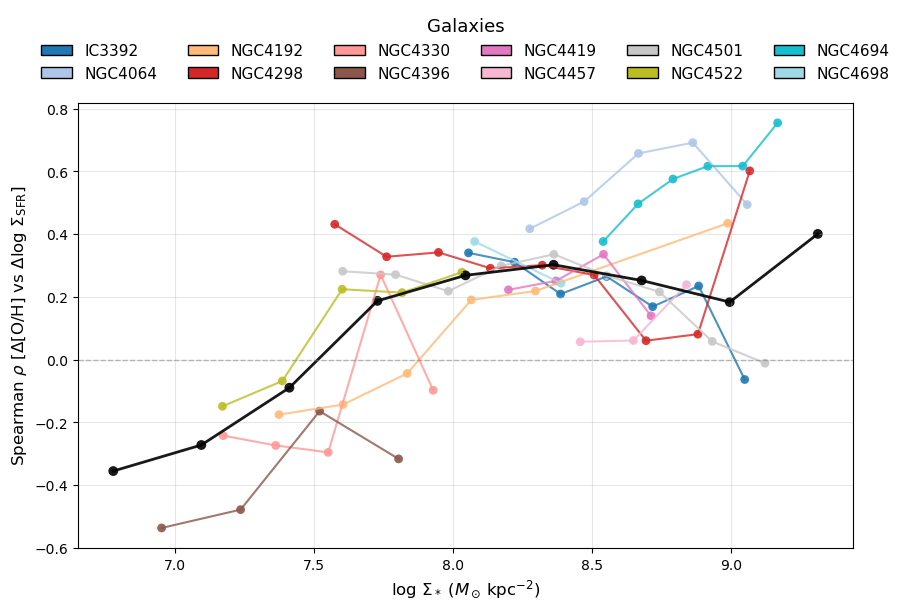

In [7]:
# ------------------------------------------------------------------
# Offset relations: Δ[O/H] vs Δlog Σ_SFR in Σ_* bins
# For all galaxies (excluding NGC4383) and Spearman rho vs Σ_* summary
# Spearman rho uses only points inside 95% contour and only if trend exists
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import matplotlib.gridspec as gridspec
from scipy.stats import spearmanr
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ------------------------------------------------------------------
# Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
    return sigM, sigSFR, oh_map, indicator_name

# ------------------------------------------------------------------
# Helper: calculate binned statistics with unique-count requirement
# ------------------------------------------------------------------
def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_unique=20):
    """Calculate median and std in x-bins, requiring >= min_unique unique y values."""
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)

    finite = np.isfinite(x_data) & np.isfinite(y_data)
    if np.sum(finite) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])

    x_min, x_max = np.nanmin(x_data[finite]), np.nanmax(x_data[finite])
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    if bin_edges.size < 2:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    medians = []
    stds = []
    counts = []
    valid_centers = []

    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = finite & (x_data >= bin_start) & (x_data < bin_end)
        if np.sum(in_bin) == 0:
            continue

        y_in_bin = y_data[in_bin]
        if len(np.unique(y_in_bin)) >= min_unique:
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])

    return (np.array(valid_centers), np.array(medians),
            np.array(stds), np.array(counts))

# ------------------------------------------------------------------
# Galaxy list and color map (reserve color for excluded galaxy)
# ------------------------------------------------------------------
all_bin_centers = []  # Σ_* bin centers for which rho is valid (per-galaxy)
all_rho_values = []     # Spearman rho (per-galaxy)
all_galaxy_indices = []

# Also store all spaxels across galaxies to compute a global trend
global_sigM_list = []
global_sigSFR_list = []
global_oh_list = []
global_gal_index_list = []

# Build full galaxy list from available FITS files (including excluded)
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies_all = [f.name.split('_')[0] for f in bins]
excluded_galaxies = {'NGC4383'}

# Build galaxy -> color mapping over ALL galaxies (so excluded keeps its color)
galaxy_colors_all = plt.cm.tab20(np.linspace(0, 1, len(galaxies_all)))
galaxy_color_dict = dict(zip(galaxies_all, galaxy_colors_all))

# Now define the working sample that EXCLUDES NGC4383 for analysis/plotting
galaxies = [g for g in galaxies_all if g not in excluded_galaxies]

print("=" * 80)
print(f"Offset relations and Spearman rho vs Σ_* (excluding: {excluded_galaxies})")
print("All galaxies (for color assignment):", ", ".join(galaxies_all))
print("Galaxies used in this analysis:", ", ".join(galaxies))
print("=" * 80)

# ------------------------------------------------------------------
# Loop over galaxies and compute Spearman rho per Σ_* bin (per-galaxy)
# and collect global spaxels for combined trend
# ------------------------------------------------------------------
for gal_index, gal in enumerate(galaxies):
    print(f"\nProcessing {gal} ...")
    try:
        sigM, sigSFR, oh_o3n2_map, indicator_name = load_maps(gal)
    except Exception as e:
        print(f"  Skipping {gal}: {e}")
        continue

    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    if np.sum(valid_all) == 0:
        print("  No valid pixels.")
        continue

    # Collect into global arrays for combined analysis
    global_sigM_list.append(sigM[valid_all].ravel())
    global_sigSFR_list.append(sigSFR[valid_all].ravel())
    global_oh_list.append(oh_o3n2_map[valid_all].ravel())
    global_gal_index_list.append(np.full(np.sum(valid_all), gal_index, dtype=int))

    # 1. Define 12 Σ_* bins for this galaxy
    n_bins = 12
    sigmaM_min = np.nanmin(sigM[valid_all])
    sigmaM_max = np.nanmax(sigM[valid_all])
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    sigmaM_bin_centers = 0.5 * (sigmaM_bin_edges[:-1] + sigmaM_bin_edges[1:])

    # 2. Global symmetric limits for this galaxy (for reference / consistency)
    global_max_abs_sfr = 0
    global_max_abs_oh = 0
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all

        if np.sum(bin_mask) > 0:
            sfr_bin = sigSFR[bin_mask]
            oh_bin = oh_o3n2_map[bin_mask]

            sfr_offset = sfr_bin - np.mean(sfr_bin)
            oh_offset = oh_bin - np.mean(oh_bin)

            if np.any(np.isfinite(sfr_offset)):
                global_max_abs_sfr = max(global_max_abs_sfr, np.nanmax(np.abs(sfr_offset)))
            if np.any(np.isfinite(oh_offset)):
                global_max_abs_oh = max(global_max_abs_oh, np.nanmax(np.abs(oh_offset)))

    print(f"  Σ* range: {sigmaM_min:.3f} to {sigmaM_max:.3f}")
    print(f"  Global Δlog(Σ_SFR) axis limits: ±{global_max_abs_sfr:.3f}")
    print(f"  Global Δ[O/H] axis limits: ±{global_max_abs_oh:.3f}")

    # 3. Compute Spearman rho in each Σ_* bin using 95% contour logic (per galaxy)
    print("  Spearman rho in each Σ_* bin (95% contour + trend, per galaxy):")
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all

        n_pixels = np.sum(bin_mask)

        if n_pixels <= 0:
            print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n=0, r=N/A")
            continue

        # Values in this Σ_* bin
        sfr_bin = sigSFR[bin_mask]
        oh_bin = oh_o3n2_map[bin_mask]

        # Offsets within this bin
        sfr_bin_mean = np.mean(sfr_bin)
        oh_bin_mean = np.mean(oh_bin)

        sfr_offset = sfr_bin - sfr_bin_mean
        oh_offset = oh_bin - oh_bin_mean

        valid_corr = np.isfinite(sfr_offset) & np.isfinite(oh_offset)

        if np.sum(valid_corr) <= 2:
            spearman_rho = np.nan
            print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r=N/A (insufficient valid points)")
            continue

        # ------------------------------------------------------------------
        # Calculate 95% contour and mask, as in the 12-panel code
        # ------------------------------------------------------------------
        contour_mask = np.zeros_like(valid_corr, dtype=bool)
        if np.sum(valid_corr) > 20:
            try:
                H, xedges, yedges = np.histogram2d(sfr_offset[valid_corr], oh_offset[valid_corr],
                                                   bins=30, density=True)
                H_flat = H.flatten()
                H_sorted = np.sort(H_flat)[::-1]
                H_cumsum = np.cumsum(H_sorted)
                H_cumsum /= H_cumsum[-1]
                threshold_95 = H_sorted[np.where(H_cumsum >= 0.95)[0][0]]

                x_centers = (xedges[:-1] + xedges[1:]) / 2
                y_centers = (yedges[:-1] + yedges[1:]) / 2

                x_idx = np.searchsorted(xedges, sfr_offset[valid_corr], side='right') - 1
                y_idx = np.searchsorted(yedges, oh_offset[valid_corr], side='right') - 1

                x_idx = np.clip(x_idx, 0, H.shape[0] - 1)
                y_idx = np.clip(y_idx, 0, H.shape[1] - 1)

                inside = H[x_idx, y_idx] >= threshold_95
                contour_mask[valid_corr] = inside
            except Exception:
                contour_mask[:] = True
        else:
            contour_mask[:] = True

        # ------------------------------------------------------------------
        # Median trend using only points inside 95% contour
        # ------------------------------------------------------------------
        x_trend = sfr_offset[contour_mask]
        y_trend = oh_offset[contour_mask]

        centers, medians, stds, counts = calculate_binned_stats(x_trend, y_trend,
                                                                bin_width=0.2,
                                                                min_unique=20)

        # Require at least 2 median-trend points for a valid trend
        has_trend = centers.size >= 2

        # ------------------------------------------------------------------
        # Spearman rho: only for points inside 95% contour and only if trend exists
        # ------------------------------------------------------------------
        if has_trend and np.sum(contour_mask & valid_corr) > 2:
            try:
                spearman_rho, spearman_p = spearmanr(sfr_offset[contour_mask & valid_corr],
                                                oh_offset[contour_mask & valid_corr])
                print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r={spearman_rho:.3f}")
            except Exception:
                spearman_rho = np.nan
                print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r=N/A (error)")
        else:
            spearman_rho = np.nan
            print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r=N/A (no trend or too few in 95%)")

        # Store only valid rho values
        if np.isfinite(spearman_rho):
            all_bin_centers.append(sigmaM_bin_centers[i])
            all_rho_values.append(spearman_rho)
            all_galaxy_indices.append(gal_index)

# ------------------------------------------------------------------
# Prepare global arrays for combined Spearman vs Σ_* (all galaxies)
# ------------------------------------------------------------------
if global_sigM_list:
    global_sigM = np.concatenate(global_sigM_list)
    global_sigSFR = np.concatenate(global_sigSFR_list)
    global_oh = np.concatenate(global_oh_list)
else:
    global_sigM = np.array([])
    global_sigSFR = np.array([])
    global_oh = np.array([])

# ------------------------------------------------------------------
# Convert collected per-galaxy Spearman rho data to arrays
# ------------------------------------------------------------------
all_bin_centers = np.array(all_bin_centers)
all_rho_values = np.array(all_rho_values)
all_galaxy_indices = np.array(all_galaxy_indices)

print("\n" + "=" * 80)
print("Summary: number of Σ_* bins with valid Spearman rho (per galaxy):", len(all_rho_values))
print("=" * 80)

# ------------------------------------------------------------------
# Compute combined Spearman rho vs Σ_* over all galaxies (same method)
# ------------------------------------------------------------------
global_bin_centers = []
global_rho_values = []

if global_sigM.size > 0:
    # Define 12 Σ_* bins for the combined sample
    n_bins_global = 12
    sigmaM_min_g = np.nanmin(global_sigM)
    sigmaM_max_g = np.nanmax(global_sigM)
    sigmaM_edges_g = np.linspace(sigmaM_min_g, sigmaM_max_g, n_bins_global + 1)
    sigmaM_centers_g = 0.5 * (sigmaM_edges_g[:-1] + sigmaM_edges_g[1:])

    print("\nComputing combined Spearman rho in Σ_* bins (all galaxies together)...")
    for i in range(n_bins_global):
        if i == 0:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM < sigmaM_edges_g[i+1])
        elif i == n_bins_global - 1:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM <= sigmaM_edges_g[i+1])
        else:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM < sigmaM_edges_g[i+1])

        n_pix_g = np.sum(bin_mask_g)
        if n_pix_g <= 0:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n=0, r=N/A")
            continue

        sfr_bin_g = global_sigSFR[bin_mask_g]
        oh_bin_g = global_oh[bin_mask_g]

        sfr_mean_g = np.mean(sfr_bin_g)
        oh_mean_g = np.mean(oh_bin_g)

        sfr_off_g = sfr_bin_g - sfr_mean_g
        oh_off_g = oh_bin_g - oh_mean_g

        valid_corr_g = np.isfinite(sfr_off_g) & np.isfinite(oh_off_g)
        if np.sum(valid_corr_g) <= 2:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r=N/A (insufficient valid points)")
            continue

        contour_mask_g = np.zeros_like(valid_corr_g, dtype=bool)
        if np.sum(valid_corr_g) > 20:
            try:
                Hg, xedges_g, yedges_g = np.histogram2d(sfr_off_g[valid_corr_g], oh_off_g[valid_corr_g],
                                                       bins=30, density=True)
                H_flat_g = Hg.flatten()
                H_sorted_g = np.sort(H_flat_g)[::-1]
                H_cumsum_g = np.cumsum(H_sorted_g)
                H_cumsum_g /= H_cumsum_g[-1]
                thr95_g = H_sorted_g[np.where(H_cumsum_g >= 0.95)[0][0]]

                xcent_g = (xedges_g[:-1] + xedges_g[1:]) / 2
                ycent_g = (yedges_g[:-1] + yedges_g[1:]) / 2

                x_idx_g = np.searchsorted(xedges_g, sfr_off_g[valid_corr_g], side='right') - 1
                y_idx_g = np.searchsorted(yedges_g, oh_off_g[valid_corr_g], side='right') - 1

                x_idx_g = np.clip(x_idx_g, 0, Hg.shape[0] - 1)
                y_idx_g = np.clip(y_idx_g, 0, Hg.shape[1] - 1)

                inside_g = Hg[x_idx_g, y_idx_g] >= thr95_g
                contour_mask_g[valid_corr_g] = inside_g
            except Exception:
                contour_mask_g[:] = True
        else:
            contour_mask_g[:] = True

        x_trend_g = sfr_off_g[contour_mask_g]
        y_trend_g = oh_off_g[contour_mask_g]

        centers_g, medians_g, stds_g, counts_g = calculate_binned_stats(x_trend_g, y_trend_g,
                                                                        bin_width=0.2,
                                                                        min_unique=20)

        has_trend_g = centers_g.size >= 3

        if has_trend_g and np.sum(contour_mask_g & valid_corr_g) > 2:
            try:
                rho_g, p_g = spearmanr(sfr_off_g[contour_mask_g & valid_corr_g],
                                     oh_off_g[contour_mask_g & valid_corr_g])
                global_bin_centers.append(sigmaM_centers_g[i])
                global_rho_values.append(rho_g)
                print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r={rho_g:.3f}")
            except Exception:
                print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r=N/A (error)")
        else:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r=N/A (no trend or too few in 95%)")

global_bin_centers = np.array(global_bin_centers)
global_rho_values = np.array(global_rho_values)

# ------------------------------------------------------------------
# Plot Spearman rho vs Σ_* for all galaxies, with galaxy color legend
# and an additional combined (all galaxies) trend in black
# ------------------------------------------------------------------
if len(all_rho_values) > 0:
    
    galaxy_indices_unique = np.unique(all_galaxy_indices)
    
    # Create figure with main axis and a thin top axis for legend
    fig = plt.figure(figsize=(10, 7))
    gs = gridspec.GridSpec(2, 1, height_ratios=[0.18, 1.0], hspace=0.05)
    legend_ax = fig.add_subplot(gs[0, 0])
    ax = fig.add_subplot(gs[1, 0])
    legend_ax.axis('off')
    
    # Plot Spearman rho vs Σ_* for each galaxy
    for idx in galaxy_indices_unique:
        mask = all_galaxy_indices == idx
        gal_name = galaxies[idx]
        color = galaxy_color_dict[gal_name]
        
        # Sort by Σ_* so lines are not scrambled
        x_vals = all_bin_centers[mask]
        y_vals = all_rho_values[mask]
        order = np.argsort(x_vals)
        x_sorted = x_vals[order]
        y_sorted = y_vals[order]
        
        ax.plot(x_sorted, y_sorted, color=color, linewidth=1.5, alpha=0.8)
        ax.scatter(x_sorted, y_sorted, color=color, s=40, alpha=0.9, edgecolors='none', rasterized=True)
    
    # Add combined trend (all galaxies together) in black (no legend entry)
    if global_rho_values.size > 0:
        order_g = np.argsort(global_bin_centers)
        ax.plot(global_bin_centers[order_g], global_rho_values[order_g],
                color='black', linewidth=2.0, alpha=0.9, linestyle='-')
        ax.scatter(global_bin_centers[order_g], global_rho_values[order_g],
                   color='black', s=50, alpha=0.9, edgecolors='none', rasterized=True)
    
    # Axis formatting
    ax.axhline(0.0, color='gray', linestyle='--', linewidth=1.0, alpha=0.5)
    ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
    ax.set_ylabel(r'Spearman $\rho$ [Δ[O/H] vs Δ$\log\,\Sigma_{\mathrm{SFR}}$]', fontsize=12)
    # ax.set_title(r'Spearman $\rho$ vs $\log\,\Sigma_*$ (all galaxies, excluding NGC4383)', fontsize=14)
    ax.grid(True, alpha=0.3)
    
    # ------------------------------------------------------------------
    # Galaxy legend at the top using dummy patches (excluding NGC4383)
    # ------------------------------------------------------------------
    galaxy_names = [galaxies[idx] for idx in galaxy_indices_unique]
    legend_elements = [
        Patch(facecolor=galaxy_color_dict[gal], edgecolor='black', label=gal)
        for gal in galaxy_names
]
    legend_ax.legend(handles=legend_elements, loc='center', ncol=min(len(galaxy_names), 6),
                      frameon=False, fontsize=11, title='Galaxies', title_fontsize=13)
    
    plt.tight_layout()
    plt.savefig('Plot_Paper_1/MAUVE_MUSE_SpearmanRho_vs_SigmaM_AllGalaxies_ExclNGC4383.png',
                dpi=600, bbox_inches='tight')
    plt.savefig('Plot_Paper_1/MAUVE_MUSE_SpearmanRho_vs_SigmaM_AllGalaxies_ExclNGC4383.pdf',
                bbox_inches='tight')
    plt.show()
else:
    print("No valid Spearman rho values to plot.")


/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_39844/1796674122.py:336: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


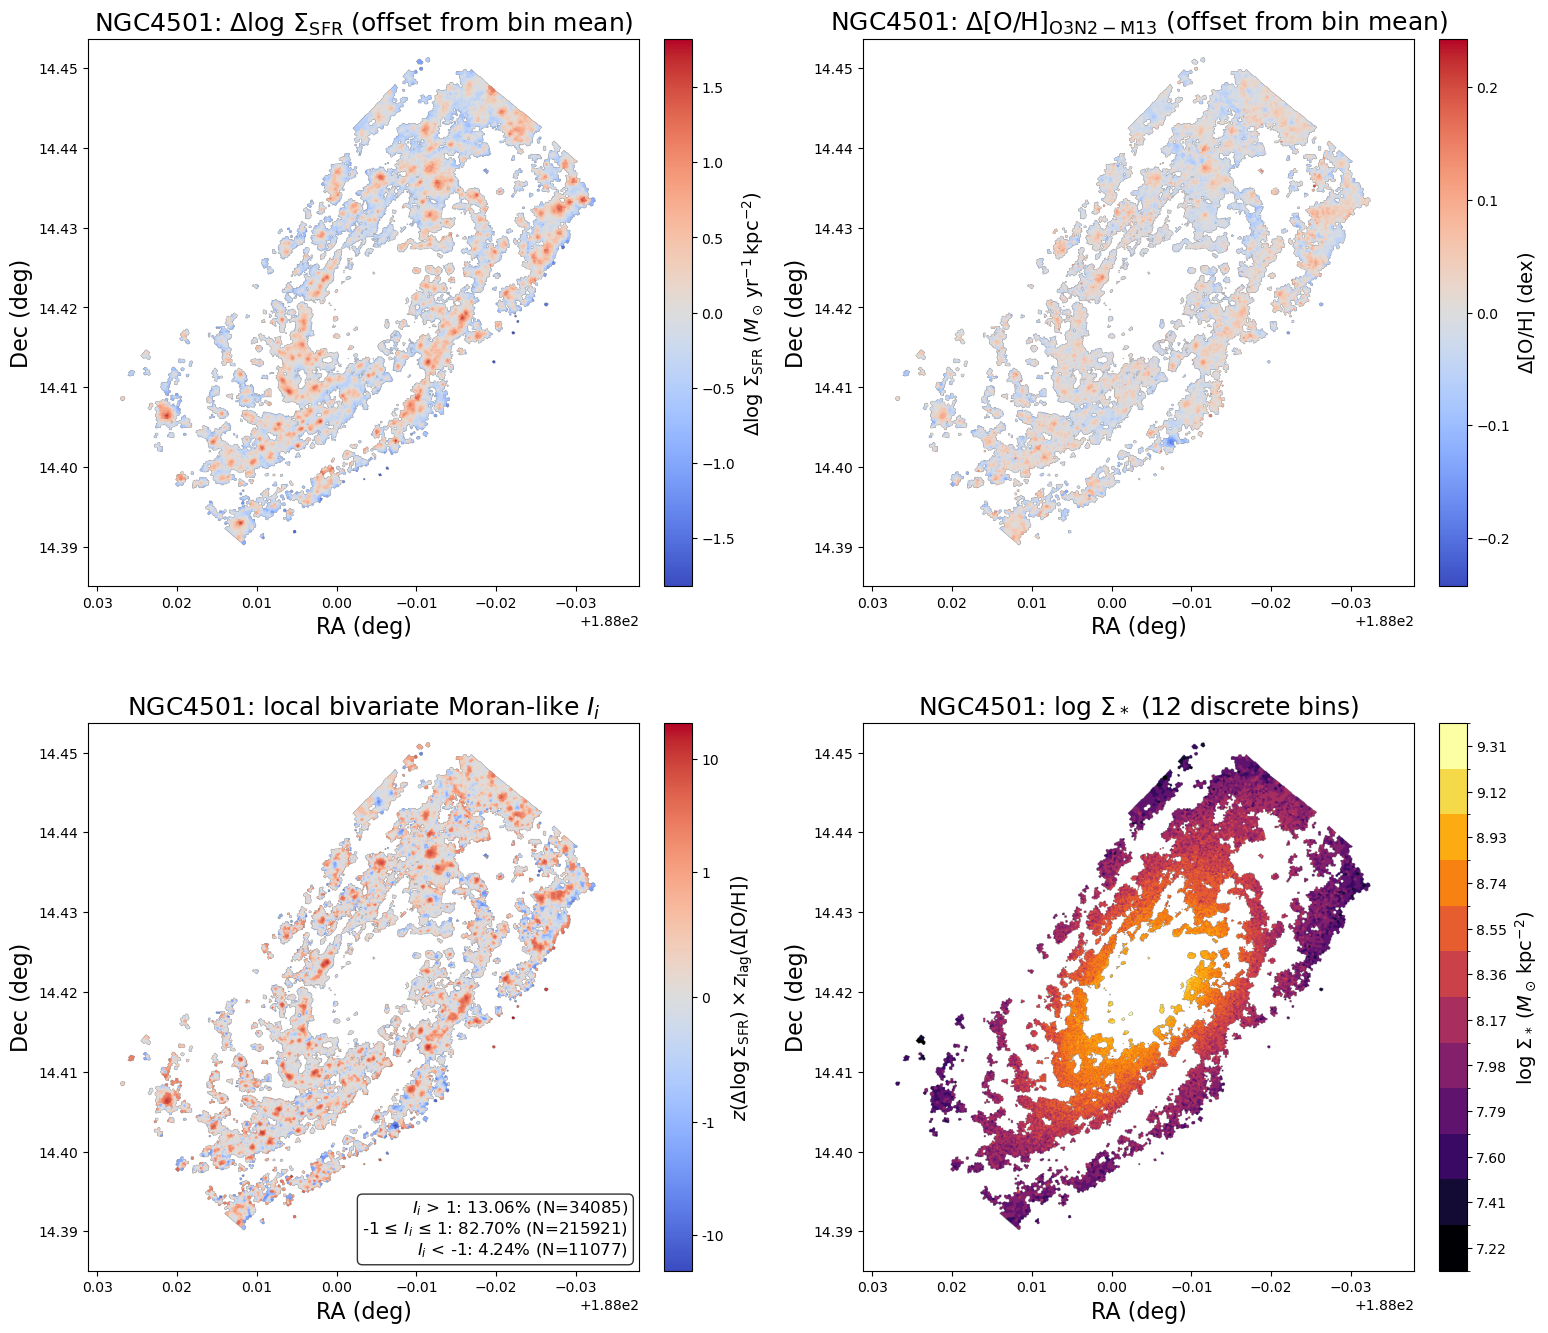


2x2 combined figure complete for NGC4501!
  Σ_SFR offset range: -1.824 to 1.824
  [O/H] offset range: -0.243 to 0.243
  Moran I_i range: -20.738 to 18.501
  Σ* bins: 12 bins from 7.128 to 9.407
  I_i > 1: 13.06% (N=34085)
  -1 ≤ I_i ≤ 1: 82.70% (N=215921)
  I_i < -1: 4.24% (N=11077)


In [8]:
# ------------------------------------------------------------------
# 2x2 Combined figure: offset maps + Moran-like map + binned Σ* map
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs_module
from matplotlib.colors import BoundaryNorm, SymLogNorm

# Only focus on NGC4501 for this visualisation
galaxies = ['NGC4501']

# ------------------------------------------------------------------
# Define threshold parameter for linear/log colorbar transition and classification
# ------------------------------------------------------------------
threshold = 1  # Values between -threshold and +threshold use linear scale

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    return sigM, sigSFR, oh_map, indicator_name, wcs, gas_header

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name, wcs_full, gas_header = load_maps(gal)

    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    # ------------------------------------------------------------------
    # 2.  Calculate offset maps (relative to Σ* bin means)
    # ------------------------------------------------------------------
    # Define 12 Σ* bins
    n_bins = 12
    sigmaM_min = np.nanmin(sigM[valid_all])
    sigmaM_max = np.nanmax(sigM[valid_all])
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    
    # Initialize offset maps
    sfr_offset = np.full_like(sigSFR, np.nan)
    oh_offset = np.full_like(oh_o3n2_map, np.nan)
    
    # Calculate offset for each Σ* bin
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        if np.sum(bin_mask) > 0:
            # Calculate bin mean and offset within this bin
            sfr_bin_mean = np.mean(sigSFR[bin_mask])
            oh_bin_mean = np.mean(oh_o3n2_map[bin_mask])
            
            sfr_offset[bin_mask] = sigSFR[bin_mask] - sfr_bin_mean
            oh_offset[bin_mask] = oh_o3n2_map[bin_mask] - oh_bin_mean
    
    sfr_offset_max = np.nanmax(np.abs(sfr_offset[valid_all]))
    oh_offset_max = np.nanmax(np.abs(oh_offset[valid_all]))
    
    # Global means for display purposes only
    sfr_mean = np.nanmean(sigSFR[valid_sfr])
    oh_mean = np.nanmean(oh_o3n2_map[valid_oh])

    # ------------------------------------------------------------------
    # 3.  Calculate local bivariate Moran-like map
    # ------------------------------------------------------------------
    def local_bivariate_moran(A, B, valid_mask, neighbourhood='queen'):
        """
        Simple Moran-style local bivariate association between A and B.

        Parameters
        ----------
        A, B : 2D arrays
            Maps (e.g. sfr_offset, oh_offset).
        valid_mask : 2D bool
            True where both maps are valid.
        neighbourhood : {'queen', 'rook'}
            'queen' = 8-connected neighbours, 'rook' = 4-connected.

        Returns
        -------
        I_map : 2D array
            Local bivariate Moran-like statistic (sign & amplitude).
        quad_map : 2D int array
            Quadrant type:
            0 = invalid / no neighbours
            1 = high A, high lag(B)
            2 = low A,  high lag(B)
            3 = low A,  low lag(B)
            4 = high A, low lag(B)
        """
        ny, nx = A.shape
        I_map = np.full_like(A, np.nan, dtype=float)
        quad_map = np.zeros_like(A, dtype=int)

        # standardise A,B on valid pixels only
        Aval = A[valid_mask]
        Bval = B[valid_mask]
        Az = (A - np.nanmean(Aval)) / np.nanstd(Aval)
        Bz = (B - np.nanmean(Bval)) / np.nanstd(Bval)

        if neighbourhood == 'queen':
            offsets = [(-1,-1), (-1,0), (-1,1),
                       ( 0,-1),          ( 0,1),
                       ( 1,-1), ( 1,0), ( 1,1)]
        elif neighbourhood == 'rook':
            offsets = [(-1,0), (0,-1), (0,1), (1,0)]
        else:
            raise ValueError("neighbourhood must be 'queen' or 'rook'")

        for i in range(ny):
            for j in range(nx):
                if not valid_mask[i, j]:
                    continue

                # collect neighbouring Bz values
                neigh_vals = []
                for dy, dx in offsets:
                    ii, jj = i + dy, j + dx
                    if 0 <= ii < ny and 0 <= jj < nx and valid_mask[ii, jj]:
                        neigh_vals.append(Bz[ii, jj])

                if len(neigh_vals) == 0:
                    continue

                lag_B = np.mean(neigh_vals)   # spatial lag of B
                I_val = Az[i, j] * lag_B      # Moran-style product
                I_map[i, j] = I_val

                # quadrant classification (like LISA maps)
                if Az[i, j] >= 0 and lag_B >= 0:
                    quad_map[i, j] = 1  # high A – high B_neigh
                elif Az[i, j] < 0 and lag_B >= 0:
                    quad_map[i, j] = 2  # low A – high B_neigh
                elif Az[i, j] < 0 and lag_B < 0:
                    quad_map[i, j] = 3  # low A – low B_neigh
                else:
                    quad_map[i, j] = 4  # high A – low B_neigh

        return I_map, quad_map

    I_map, quad_map = local_bivariate_moran(sfr_offset, oh_offset, valid_all,
                                            neighbourhood='queen')

    # ------------------------------------------------------------------
    # Calculate statistics for three classes based on threshold
    # ------------------------------------------------------------------
    valid_I = np.isfinite(I_map)
    n_total = np.sum(valid_I)
    n_high = np.sum(I_map[valid_I] > threshold)
    n_mid = np.sum((I_map[valid_I] >= -threshold) & (I_map[valid_I] <= threshold))
    n_low = np.sum(I_map[valid_I] < -threshold)
    pct_high = (n_high / n_total * 100) if n_total > 0 else 0
    pct_mid = (n_mid / n_total * 100) if n_total > 0 else 0
    pct_low = (n_low / n_total * 100) if n_total > 0 else 0

    # ------------------------------------------------------------------
    # 4.  Create binned Σ* map
    # ------------------------------------------------------------------
    sigM_binned_map = np.full_like(sigM, np.nan)
    
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        # Assign bin center value
        bin_center = (sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2
        sigM_binned_map[bin_mask] = bin_center

    # ------------------------------------------------------------------
    # 5.  Prepare coordinate extent
    # ------------------------------------------------------------------
    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]

    # ------------------------------------------------------------------
    # 6.  Create 2x2 figure
    # ------------------------------------------------------------------
    fig = plt.figure(figsize=(18, 16))
    gs = gs_module.GridSpec(2, 2, figure=fig, hspace=0.25, wspace=0.25)

    # Top-left: Σ_SFR offset map
    ax1 = fig.add_subplot(gs[0, 0])
    im_sfr = ax1.imshow(np.ma.masked_invalid(sfr_offset), origin='lower', cmap='coolwarm',
                        extent=extent, vmin=-sfr_offset_max, vmax=sfr_offset_max)
    ax1.set_title(rf'{gal}: $\Delta\log\,\Sigma_{{\mathrm{{SFR}}}}$ (offset from bin mean)', fontsize=18)
    ax1.set_xlabel('RA (deg)', fontsize=16)
    ax1.set_ylabel('Dec (deg)', fontsize=16)
    
    cbar_sfr = fig.colorbar(im_sfr, ax=ax1, fraction=0.046, pad=0.04)
    cbar_sfr.set_label(r'$\Delta\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=14)

    # Top-right: [O/H] offset map
    ax2 = fig.add_subplot(gs[0, 1])
    im_oh = ax2.imshow(np.ma.masked_invalid(oh_offset), origin='lower', cmap='coolwarm',
                       extent=extent, vmin=-oh_offset_max, vmax=oh_offset_max)
    ax2.set_title(rf'{gal}: $\Delta$[O/H]$_{{\mathrm{{{indicator_name}}}}}$ (offset from bin mean)', fontsize=18)
    ax2.set_xlabel('RA (deg)', fontsize=16)
    ax2.set_ylabel('Dec (deg)', fontsize=16)
    
    cbar_oh = fig.colorbar(im_oh, ax=ax2, fraction=0.046, pad=0.04)
    cbar_oh.set_label(r'$\Delta$[O/H] (dex)', fontsize=14)

    # Bottom-left: Moran-like bivariate map with SymLogNorm
    ax3 = fig.add_subplot(gs[1, 0])
    
    # max absolute value for symmetric limits
    vI = np.nanmax(np.abs(I_map))
    
    # Symmetric log-normalisation using threshold parameter:
    #  - values between -threshold and +threshold are on a linear scale
    #  - outside this, log10 scaling, symmetric around 0
    norm = SymLogNorm(linthresh=threshold, linscale=1.0,
                      vmin=-vI, vmax=vI, base=10)
    
    imI = ax3.imshow(np.ma.masked_invalid(I_map), origin='lower',
                     cmap='coolwarm', extent=extent, norm=norm)
    ax3.set_title(rf'{gal}: local bivariate Moran-like $I_i$', fontsize=18)
    ax3.set_xlabel('RA (deg)', fontsize=16)
    ax3.set_ylabel('Dec (deg)', fontsize=16)
    
    cbarI = fig.colorbar(imI, ax=ax3, fraction=0.046, pad=0.04)
    cbarI.set_label(r'$z(\Delta\log\Sigma_{\rm SFR}) \times z_{\rm lag}(\Delta{\rm [O/H]})$', fontsize=14)
    
    # Symmetric log-style ticks including ±threshold
    # Build positive log ticks
    max_pow = int(np.floor(np.log10(vI)))
    pos_ticks = [10**k for k in range(0, max_pow+1) if 10**k <= vI]
    
    # Combine: negative log ticks + -threshold + 0 + threshold + positive log ticks
    # Remove threshold from pos_ticks if it's already a power of 10
    pos_ticks_filtered = [p for p in pos_ticks if p != threshold]
    neg_ticks_filtered = [-p for p in reversed(pos_ticks_filtered)]
    
    ticks = neg_ticks_filtered + [-threshold, 0.0, threshold] + pos_ticks_filtered
    # Sort and remove duplicates
    ticks = sorted(set(ticks))
    
    cbarI.set_ticks(ticks)
    cbarI.set_ticklabels([f'{t:g}' for t in ticks])
    
    # Add legend for three classes based on threshold
    # Find best location by checking which corner has most NaN values
    ny, nx = I_map.shape
    corner_size = min(ny // 4, nx // 4)  # Check a quarter of the image size
    
    # Count NaN pixels in each corner
    corners = {
        'bottom_left': np.sum(np.isnan(I_map[:corner_size, :corner_size])),
        'bottom_right': np.sum(np.isnan(I_map[:corner_size, -corner_size:])),
        'top_left': np.sum(np.isnan(I_map[-corner_size:, :corner_size])),
        'top_right': np.sum(np.isnan(I_map[-corner_size:, -corner_size:]))
    }
    
    # Choose corner with most NaN values
    best_corner = max(corners, key=corners.get)
    
    # Set position and alignment based on best corner
    if best_corner == 'bottom_left':
        x_pos, y_pos = 0.02, 0.02
        va, ha = 'bottom', 'left'
    elif best_corner == 'bottom_right':
        x_pos, y_pos = 0.98, 0.02
        va, ha = 'bottom', 'right'
    elif best_corner == 'top_left':
        x_pos, y_pos = 0.02, 0.98
        va, ha = 'top', 'left'
    else:  # top_right
        x_pos, y_pos = 0.98, 0.98
        va, ha = 'top', 'right'
    
    legend_text = f'$I_i$ > {threshold}: {pct_high:.2f}% (N={n_high})\n-{threshold} ≤ $I_i$ ≤ {threshold}: {pct_mid:.2f}% (N={n_mid})\n$I_i$ < -{threshold}: {pct_low:.2f}% (N={n_low})'
    ax3.text(x_pos, y_pos, legend_text, transform=ax3.transAxes, 
            fontsize=12, verticalalignment=va, horizontalalignment=ha,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Bottom-right: Discrete Σ* binned map
    ax4 = fig.add_subplot(gs[1, 1])
    
    cmap_discrete = plt.cm.inferno
    norm_discrete = BoundaryNorm(sigmaM_bin_edges, cmap_discrete.N)
    
    im_sigM_binned = ax4.imshow(np.ma.masked_invalid(sigM_binned_map), origin='lower', 
                                cmap=cmap_discrete, norm=norm_discrete, extent=extent)
    ax4.set_title(rf'{gal}: $\log\,\Sigma_*$ ({n_bins} discrete bins)', fontsize=18)
    ax4.set_xlabel('RA (deg)', fontsize=16)
    ax4.set_ylabel('Dec (deg)', fontsize=16)
    
    cbar_binned = fig.colorbar(im_sigM_binned, ax=ax4, fraction=0.046, pad=0.04)
    cbar_binned.set_label(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=14)
    
    # Set colorbar ticks at bin centers
    bin_centers = [(sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2 for i in range(n_bins)]
    cbar_binned.set_ticks(bin_centers)
    cbar_binned.set_ticklabels([f'{bc:.2f}' for bc in bin_centers])

    plt.tight_layout()
    plt.savefig(f'Plot_Paper_1/{gal}_correlation_map_moran.png', dpi=600, bbox_inches='tight')
    plt.savefig(f'Plot_Paper_1/{gal}_correlation_map_moran.pdf', bbox_inches='tight')
    plt.show()

    print(f"\n2x2 combined figure complete for {gal}!")
    print(f"  Σ_SFR offset range: {-sfr_offset_max:.3f} to {sfr_offset_max:.3f}")
    print(f"  [O/H] offset range: {-oh_offset_max:.3f} to {oh_offset_max:.3f}")
    print(f"  Moran I_i range: {np.nanmin(I_map):.3f} to {np.nanmax(I_map):.3f}")
    print(f"  Σ* bins: {n_bins} bins from {sigmaM_min:.3f} to {sigmaM_max:.3f}")
    print(f"  I_i > {threshold}: {pct_high:.2f}% (N={n_high})")
    print(f"  -{threshold} ≤ I_i ≤ {threshold}: {pct_mid:.2f}% (N={n_mid})")
    print(f"  I_i < -{threshold}: {pct_low:.2f}% (N={n_low})")
